# 04 — Agente RL para Alert Triage
## Network Anomaly Detection — NSL-KDD

**Metodología:** CRISP-DM — Fase 4/5 (Modeling + Evaluation)  
**Componente:** Q-Learning tabular sobre predicciones del mejor modelo ML

### Diseño del agente
| Componente | Detalle |
|---|---|
| Estados | 60 = 5 clases × 4 confianzas × 3 niveles fp_rate |
| Acciones | 3: IGNORAR / MONITOREAR / ESCALAR |
| Recompensa | Tabla de costos COT (config.yaml) |
| Constraint | System Recall ≥ 0.90 |
| Contexto | MongoDB: ventana deslizante de 100 decisiones |

### Baselines de comparación
1. **Escalar Todo** — upper bound de recall, máximo costo
2. **Threshold ≥ 0.85** — regla fija sin contexto
3. **GBT Argmax** — clasificador sin capa de decisión RL
4. **Q-Learning** — agente entrenado (este notebook)

### Reglas anti-leakage
- El agente se entrena **SOLO** sobre predicciones de `train`
- Threshold del Autoencoder ya calibrado en `val` (no se toca)
- Test se evalúa **UNA SOLA VEZ** al final

## 0. Setup

In [1]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml

from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassificationModel

from train_rl_agent import (
    QLearningAgent, AlertEnvironment, MongoWindow, RLTrainer, RLEvaluator,
    BaselineEscalateAll, BaselineThreshold, BaselineGBTArgmax,
    build_state, N_STATES, N_ACTIONS, ACTIONS
)

SEED = 42
np.random.seed(SEED)

# Cargar config
with open('../configs/config.yaml') as f:
    config = yaml.safe_load(f)

with open('../configs/pipeline_meta.json') as f:
    meta = json.load(f)

label_mapping = {int(k): v for k, v in meta['label_mapping'].items()}
print(f'Label mapping: {label_mapping}')
print(f'Costos: {config["costs"]}')
print(f'Recall mínimo requerido: {config["recall_threshold"]}')

Label mapping: {0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
Costos: {'fn_attack': 15, 'fn_dos': 20, 'fp_normal': 2, 'escalation': 1, 'tn_saving': -1}
Recall mínimo requerido: 0.9


## 1. Cargar predicciones del mejor modelo ML

El agente RL opera **sobre las predicciones** del mejor modelo ML (RF o GBT).  
No reentrenamos el modelo — solo usamos sus predicciones como input del entorno.

In [2]:
spark = SparkSession.builder \
    .appName('NetworkAnomalyDetection_RL') \
    .master('local[*]') \
    .config('spark.driver.memory', '4g') \
    .config('spark.ui.showConsoleProgress', 'false') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print(f'PySpark {spark.version}')

# Cargar datasets procesados
base = '../data/processed'
train_df = spark.read.parquet(f'{base}/train_features.parquet')
val_df   = spark.read.parquet(f'{base}/val_features.parquet')
test_df  = spark.read.parquet(f'{base}/test_features.parquet')

print(f'Train: {train_df.count():,} | Val: {val_df.count():,} | Test: {test_df.count():,}')

26/05/31 12:54:41 WARN Utils: Your hostname, MacBook-Pro-3.local resolves to a loopback address: 127.0.0.1; using 192.168.0.90 instead (on interface en0)
26/05/31 12:54:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/31 12:54:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark 3.5.1


Train: 88,726 | Val: 18,780 | Test: 18,467


In [3]:
# Cargar el mejor modelo ML (Random Forest por defecto)
# Si GBT fue mejor en 03_modeling, cambia la ruta aquí
best_model_path = '../models/random_forest'

try:
    best_ml_model = RandomForestClassificationModel.load(best_model_path)
    print(f'✓ Modelo cargado: {best_model_path}')
    print(f'  numTrees={best_ml_model.getNumTrees}')
except Exception as e:
    print(f'⚠ Error cargando RF: {e}')
    print('  Intenta con GBT: cambiar best_model_path a "../models/gbt"')
    raise

✓ Modelo cargado: ../models/random_forest
  numTrees=100


In [4]:
from pyspark.sql import functions as F

def extract_predictions(df, model):
    """
    Genera predicciones del modelo ML y extrae:
      - predicted_class (int)
      - predicted_proba (float): probabilidad máxima
      - predicted_label (str): nombre de clase
      - true_label (str): etiqueta real
    """
    preds = model.transform(df)
    
    # Extraer probabilidad máxima como confianza
    from pyspark.ml.functions import vector_to_array
    preds = preds.withColumn('proba_array', vector_to_array('probability'))
    preds = preds.withColumn('predicted_proba', F.array_max('proba_array'))
    
    result = preds.select(
        'attack_category',
        'prediction',
        'predicted_proba'
    ).toPandas()
    
    result.columns = ['true_label', 'predicted_class', 'predicted_proba']
    result['predicted_class'] = result['predicted_class'].astype(int)
    result['predicted_label'] = result['predicted_class'].map(label_mapping)
    return result

print('Generando predicciones del modelo ML en train...')
train_preds = extract_predictions(train_df, best_ml_model)
print(f'✓ Train: {len(train_preds):,} filas')

print('Generando predicciones en val...')
val_preds = extract_predictions(val_df, best_ml_model)
print(f'✓ Val:   {len(val_preds):,} filas')

print('Generando predicciones en test...')
test_preds = extract_predictions(test_df, best_ml_model)
print(f'✓ Test:  {len(test_preds):,} filas')

# Guardar para uso posterior (sin necesidad de Spark)
train_preds.to_parquet('../data/processed/train_ml_preds.parquet', index=False)
val_preds.to_parquet('../data/processed/val_ml_preds.parquet', index=False)
test_preds.to_parquet('../data/processed/test_ml_preds.parquet', index=False)
print('✓ Predicciones guardadas en data/processed/')

spark.stop()
print('✓ SparkSession cerrada')

Generando predicciones del modelo ML en train...


✓ Train: 88,726 filas
Generando predicciones en val...


✓ Val:   18,780 filas
Generando predicciones en test...


✓ Test:  18,467 filas


✓ Predicciones guardadas en data/processed/


✓ SparkSession cerrada


## 2. Distribución de predicciones ML (análisis previo al RL)

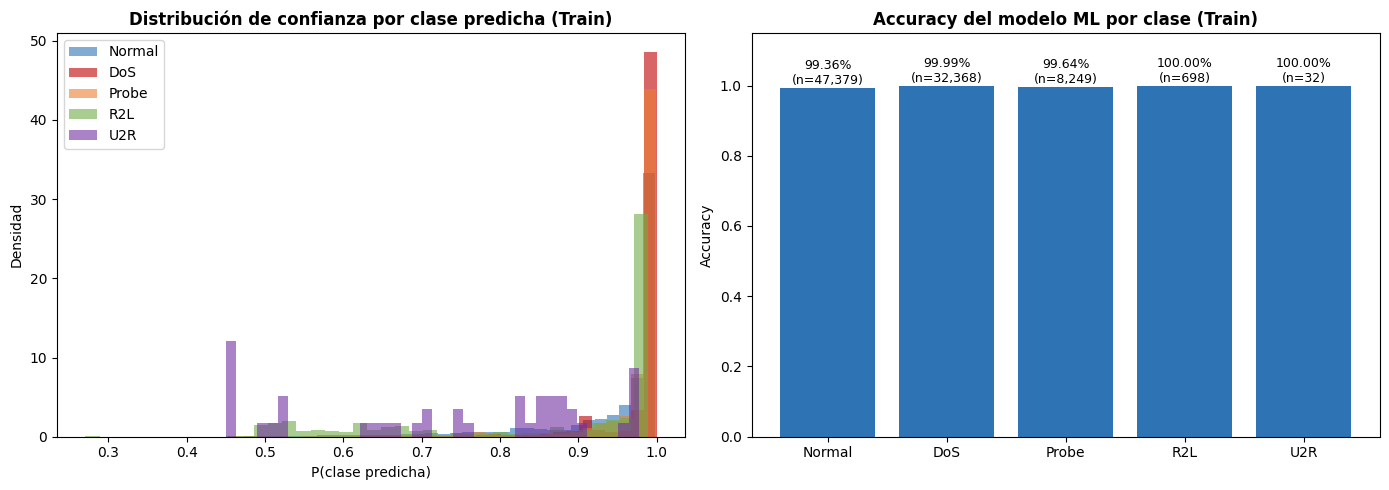

✓ Guardado: reports/08_ml_predictions_analysis.png


In [5]:
# Distribución de confianza por clase predicha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de confianza
classes_order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
colors = ['#2E74B5', '#C00000', '#ED7D31', '#70AD47', '#7030A0']
for cls, col in zip(classes_order, colors):
    subset = train_preds[train_preds['predicted_label'] == cls]['predicted_proba']
    if len(subset) > 0:
        axes[0].hist(subset, bins=40, alpha=0.6, label=cls, color=col, density=True)
axes[0].set_title('Distribución de confianza por clase predicha (Train)', fontweight='bold')
axes[0].set_xlabel('P(clase predicha)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Accuracy por clase (% bien clasificados)
acc_by_cls = []
for cls in classes_order:
    subset = train_preds[train_preds['true_label'] == cls]
    if len(subset) > 0:
        acc = (subset['true_label'] == subset['predicted_label']).mean()
        acc_by_cls.append({'clase': cls, 'accuracy': acc, 'n': len(subset)})

acc_df = pd.DataFrame(acc_by_cls)
bar_colors = ['#C00000' if a < 0.7 else '#2E74B5' for a in acc_df['accuracy']]
axes[1].bar(acc_df['clase'], acc_df['accuracy'], color=bar_colors)
for i, (acc, n) in enumerate(zip(acc_df['accuracy'], acc_df['n'])):
    axes[1].text(i, acc + 0.01, f'{acc:.2%}\n(n={n:,})', ha='center', fontsize=9)
axes[1].set_title('Accuracy del modelo ML por clase (Train)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('../reports/08_ml_predictions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: reports/08_ml_predictions_analysis.png')

## 3. Inicializar componentes del agente RL

In [6]:
# Ventana MongoDB (auto-fallback a deque si MongoDB no está disponible)
mongo_window = MongoWindow(
    window_size=config['rl_agent']['window_size'],
    db='secureops',
    collection='decisions'
)

# Entorno
env = AlertEnvironment(
    config=config,
    label_mapping=label_mapping,
    mongo_window=mongo_window
)

# Agente Q-Learning
agent = QLearningAgent(config=config, seed=SEED)

print(f'✓ Entorno inicializado')
print(f'  Costos: {config["costs"]}')
print(f'  Recall mínimo: {config["recall_threshold"]}')
print(f'\n✓ Agente Q-Learning inicializado')
print(f'  Tabla Q: {agent.Q.shape}  ({agent.Q.size} valores)')
print(f'  ε inicial: {agent.epsilon}  |  ε final: {agent.epsilon_end}')

⚠ MongoWindow: MongoDB no disponible (No module named 'pymongo'). Usando deque en memoria.
✓ Entorno inicializado
  Costos: {'fn_attack': 15, 'fn_dos': 20, 'fp_normal': 2, 'escalation': 1, 'tn_saving': -1}
  Recall mínimo: 0.9

✓ Agente Q-Learning inicializado
  Tabla Q: (60, 3)  (180 valores)
  ε inicial: 1.0  |  ε final: 0.05


## 4. Entrenamiento del agente Q-Learning

In [7]:
trainer = RLTrainer(
    agent=agent,
    env=env,
    config=config,
    seed=SEED
)

# Entrenar en train_preds
history = trainer.train(
    predictions_df=train_preds,
    n_epochs=15,
    verbose=True
)

# Guardar agente entrenado
agent.save('../models/rl_agent')


ENTRENAMIENTO Q-LEARNING — Alert Triage Agent
  Episodios (epochs): 15
  Alertas por epoch:  88,726
  Estados: 60  |  Acciones: 3
  α=0.1  γ=0.9  ε=1.0


  Epoch   1/15 | COT=373874.0 | Recall=0.3323 ⚠ RECALL BAJO | ε=0.9950


  Epoch   2/15 | COT=374961.0 | Recall=0.3402 ⚠ RECALL BAJO | ε=0.9900


  Epoch   3/15 | COT=372330.0 | Recall=0.3365 ⚠ RECALL BAJO | ε=0.9851


  Epoch   4/15 | COT=368564.0 | Recall=0.3436 ⚠ RECALL BAJO | ε=0.9801


...

  Epoch  11/15 | COT=355838.0 | Recall=0.3660 ⚠ RECALL BAJO | ε=0.9464


  Epoch  12/15 | COT=356179.0 | Recall=0.3687 ⚠ RECALL BAJO | ε=0.9416


  Epoch  13/15 | COT=352285.0 | Recall=0.3725 ⚠ RECALL BAJO | ε=0.9369


  Epoch  14/15 | COT=350524.0 | Recall=0.3766 ⚠ RECALL BAJO | ε=0.9322


  Epoch  15/15 | COT=351168.0 | Recall=0.3771 ⚠ RECALL BAJO | ε=0.9276

✓ Entrenamiento completado — ε final: 0.9276
✓ Agente RL guardado → ../models/rl_agent/


## 5. Curvas de aprendizaje

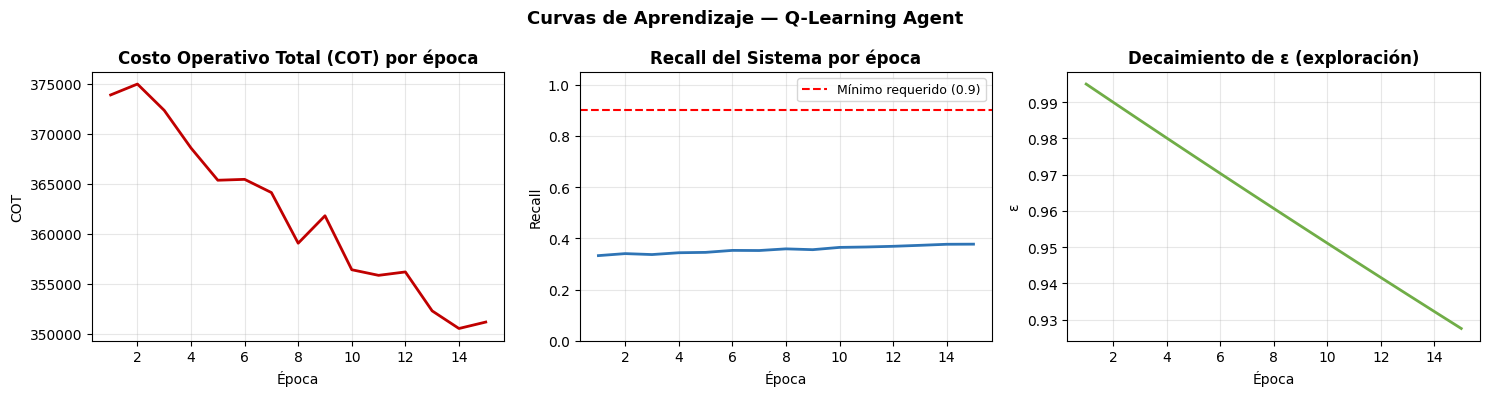

✓ Guardado: reports/09_rl_learning_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, len(history['cot']) + 1)

# COT por época
axes[0].plot(epochs, history['cot'], color='#C00000', linewidth=2)
axes[0].set_title('Costo Operativo Total (COT) por época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('COT')
axes[0].grid(True, alpha=0.3)

# Recall del sistema
axes[1].plot(epochs, history['recall'], color='#2E74B5', linewidth=2)
axes[1].axhline(config['recall_threshold'], color='red', linestyle='--',
                linewidth=1.5, label=f'Mínimo requerido ({config["recall_threshold"]})')
axes[1].set_title('Recall del Sistema por época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Epsilon (exploración)
axes[2].plot(epochs, history['epsilon'], color='#70AD47', linewidth=2)
axes[2].set_title('Decaimiento de ε (exploración)', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('ε')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Q-Learning Agent', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/09_rl_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: reports/09_rl_learning_curves.png')

## 6. Tabla Q — visualización

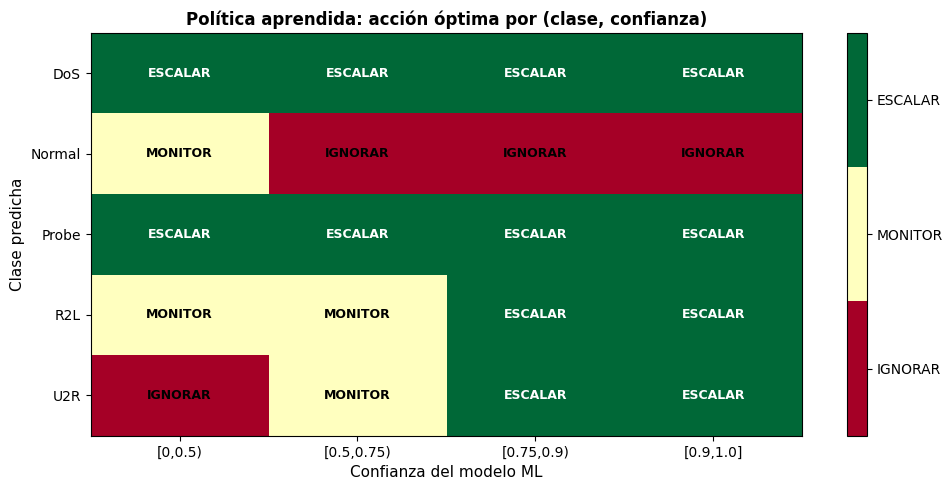

✓ Guardado: reports/10_q_table_policy.png


In [9]:
# Heatmap de la tabla Q (acción con mayor Q por estado)
from train_rl_agent import N_CLASSES, N_CONF, N_FP

classes_list = [label_mapping[i] for i in sorted(label_mapping.keys())]
conf_labels  = ['[0,0.5)', '[0.5,0.75)', '[0.75,0.9)', '[0.9,1.0]']
fp_labels    = ['fp<10%', '10%≤fp<30%', 'fp≥30%']
action_names = ['IGNORAR', 'MONITOR', 'ESCALAR']

# Tabla: para cada (clase, confianza) — acción más frecuente ignorando fp
# (proyección 2D sobre los primeros 2 ejes)
best_action_grid = np.zeros((N_CLASSES, N_CONF), dtype=int)
for c in range(N_CLASSES):
    for cf in range(N_CONF):
        # Promediar sobre niveles de fp
        qs = [agent.Q[c * N_CONF * N_FP + cf * N_FP + fp] for fp in range(N_FP)]
        q_avg = np.mean(qs, axis=0)
        best_action_grid[c, cf] = np.argmax(q_avg)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.get_cmap('RdYlGn', 3)
im = ax.imshow(best_action_grid, cmap=cmap, vmin=-0.5, vmax=2.5, aspect='auto')

ax.set_xticks(range(N_CONF))
ax.set_xticklabels(conf_labels, fontsize=10)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(classes_list, fontsize=10)
ax.set_xlabel('Confianza del modelo ML', fontsize=11)
ax.set_ylabel('Clase predicha', fontsize=11)
ax.set_title('Política aprendida: acción óptima por (clase, confianza)', fontweight='bold')

for c in range(N_CLASSES):
    for cf in range(N_CONF):
        a = best_action_grid[c, cf]
        ax.text(cf, c, action_names[a], ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if a == 2 else 'black')

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(action_names)
plt.tight_layout()
plt.savefig('../reports/10_q_table_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: reports/10_q_table_policy.png')

## 7. Evaluación en Validation — Comparativa de 4 políticas

In [10]:
# Índice numérico de 'Normal' en label_mapping
normal_idx = [k for k, v in label_mapping.items() if v == 'Normal'][0]
print(f'Índice de Normal: {normal_idx}')

# Definir políticas
policies = [
    BaselineEscalateAll(),
    BaselineThreshold(threshold=0.85, normal_label=normal_idx),
    BaselineGBTArgmax(normal_label=normal_idx),
    agent,  # Q-Learning
]
# Nombre del agente
agent.name = 'Q-Learning'

evaluator = RLEvaluator(config=config, label_mapping=label_mapping)

val_results = []
for policy in policies:
    result = evaluator.evaluate_policy(policy, val_preds, dataset_name='Val')
    val_results.append(result)
    recall_flag = '✓' if result['recall_OK'] else '⚠'
    print(f"  {result['policy']:20s}: COT={result['COT']:8,.1f} | "
          f"Recall={result['recall_sistema']:.4f} {recall_flag} | "
          f"F1={result['f1_binario']:.4f}")

comp_val = evaluator.compare(val_results)
print('\nComparativa completa (Val):')
print(comp_val[['policy', 'COT', 'COT_por_alerta', 'recall_sistema', 
                'f1_binario', 'pct_IGNORAR', 'pct_ESCALAR', 'recall_OK'
               ]].to_string(index=False))

Índice de Normal: 1


  Escalar Todo        : COT=38,964.0 | Recall=1.0000 ✓ | F1=0.6326


  Threshold (p≥0.85)  : COT= 1,558.0 | Recall=0.9590 ✓ | F1=0.9789


  GBT Argmax          : COT=  -846.0 | Recall=0.9979 ✓ | F1=0.9947


  Q-Learning          : COT= 4,452.0 | Recall=0.9870 ✓ | F1=0.9369

Comparativa completa (Val):
            policy     COT  COT_por_alerta  recall_sistema  f1_binario  pct_IGNORAR  pct_ESCALAR  recall_OK
        GBT Argmax  -846.0         -0.0450          0.9979      0.9947       0.5344       0.4656       True
Threshold (p≥0.85)  1558.0          0.0830          0.9590      0.9789       0.4561       0.4439       True
        Q-Learning  4452.0          0.2371          0.9870      0.9369       0.4840       0.5121       True
      Escalar Todo 38964.0          2.0748          1.0000      0.6326       0.0000       1.0000       True


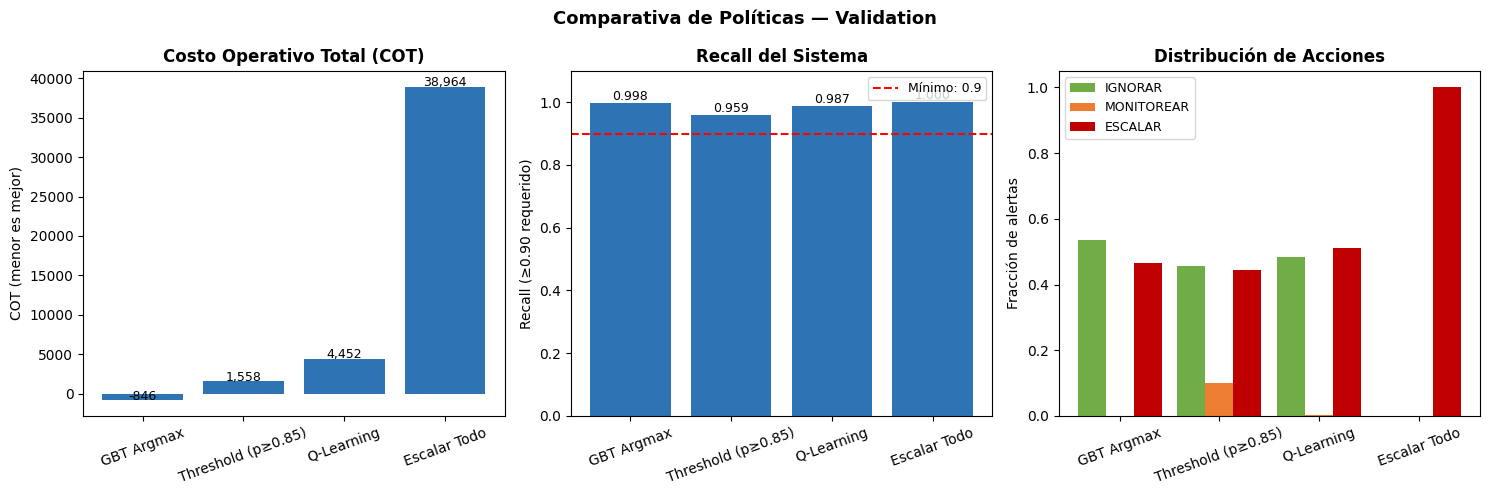

✓ Guardado: reports/policy_comparison_val.csv


In [11]:
# Visualizar comparativa en Val
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

policy_names = comp_val['policy'].tolist()
colors_bar = ['#C00000' if not r else '#2E74B5'
              for r in comp_val['recall_OK'].tolist()]

# COT total
axes[0].bar(policy_names, comp_val['COT'], color=colors_bar)
axes[0].set_title('Costo Operativo Total (COT)', fontweight='bold')
axes[0].set_ylabel('COT (menor es mejor)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(comp_val['COT']):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=9)

# Recall del sistema
axes[1].bar(policy_names, comp_val['recall_sistema'], color=colors_bar)
axes[1].axhline(config['recall_threshold'], color='red', linestyle='--',
                linewidth=1.5, label=f'Mínimo: {config["recall_threshold"]}')
axes[1].set_title('Recall del Sistema', fontweight='bold')
axes[1].set_ylabel('Recall (≥0.90 requerido)')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(comp_val['recall_sistema']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Distribución de acciones
x = np.arange(len(policy_names))
w = 0.28
axes[2].bar(x - w, comp_val['pct_IGNORAR'],   w, label='IGNORAR',   color='#70AD47')
axes[2].bar(x,     comp_val['pct_MONITOREAR'],w, label='MONITOREAR', color='#ED7D31')
axes[2].bar(x + w, comp_val['pct_ESCALAR'],   w, label='ESCALAR',    color='#C00000')
axes[2].set_title('Distribución de Acciones', fontweight='bold')
axes[2].set_ylabel('Fracción de alertas')
axes[2].set_xticks(x)
axes[2].set_xticklabels(policy_names, rotation=20)
axes[2].legend(fontsize=9)

plt.suptitle('Comparativa de Políticas — Validation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/11_policy_comparison_val.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar resultados
comp_val.to_csv('../reports/policy_comparison_val.csv', index=False)
print('✓ Guardado: reports/policy_comparison_val.csv')

## 8. Análisis de la política aprendida — Val

In [12]:
# Qué hace el agente por clase vs baseline
agent_row = comp_val[comp_val['policy'] == 'Q-Learning'].iloc[0]
baseline_row = comp_val[comp_val['policy'] == 'Escalar Todo'].iloc[0]

print('=== ANÁLISIS DEL AGENTE Q-LEARNING (Val) ===')
print(f"  COT: {agent_row['COT']:,.1f}  vs  Escalar Todo: {baseline_row['COT']:,.1f}")
cot_reduction = (baseline_row['COT'] - agent_row['COT']) / baseline_row['COT'] * 100
print(f"  Reducción de COT: {cot_reduction:.1f}%")
print(f"  Recall sistema:  {agent_row['recall_sistema']:.4f} ",
      '✓ CUMPLE' if agent_row['recall_OK'] else '⚠ INCUMPLE', 'constraint')
print(f"  % IGNORAR:      {agent_row['pct_IGNORAR']:.1%}")
print(f"  % MONITOREAR:   {agent_row['pct_MONITOREAR']:.1%}")
print(f"  % ESCALAR:      {agent_row['pct_ESCALAR']:.1%}")

# Análisis por clase: qué acción toma el agente cuando predice cada clase
print('\nAcciones del agente por clase predicha (Val):')
from train_rl_agent import build_state

for cls_idx, cls_name in sorted(label_mapping.items()):
    subset = val_preds[val_preds['predicted_class'] == cls_idx]
    if len(subset) == 0:
        continue
    action_dist = {0: 0, 1: 0, 2: 0}
    for _, row in subset.iterrows():
        state  = build_state(int(row['predicted_class']),
                             float(row['predicted_proba']), 0.0)
        action = agent.select_action(state, training=False)
        action_dist[action] += 1
    total = sum(action_dist.values())
    print(f"  {cls_name:10s} (n={total:5,}): "
          f"IGNORAR={action_dist[0]/total:.1%}  "
          f"MONITOR={action_dist[1]/total:.1%}  "
          f"ESCALAR={action_dist[2]/total:.1%}")

=== ANÁLISIS DEL AGENTE Q-LEARNING (Val) ===
  COT: 4,452.0  vs  Escalar Todo: 38,964.0
  Reducción de COT: 88.6%
  Recall sistema:  0.9870  ✓ CUMPLE constraint
  % IGNORAR:      48.4%
  % MONITOREAR:   0.4%
  % ESCALAR:      51.2%

Acciones del agente por clase predicha (Val):
  DoS        (n=6,830): IGNORAR=6.3%  MONITOR=0.0%  ESCALAR=93.7%


  Normal     (n=10,036): IGNORAR=6.7%  MONITOR=0.0%  ESCALAR=93.3%


  Probe      (n=1,718): IGNORAR=7.5%  MONITOR=0.0%  ESCALAR=92.5%
  R2L        (n=  190): IGNORAR=100.0%  MONITOR=0.0%  ESCALAR=0.0%
  U2R        (n=    6): IGNORAR=100.0%  MONITOR=0.0%  ESCALAR=0.0%


## 9. Evaluación FINAL en Test

> ⚠️ **Esta celda se ejecuta UNA SOLA VEZ.** No se permite re-tuning después de ver los resultados del test.

In [13]:
print('EVALUACIÓN FINAL EN TEST — 4 Políticas')
print('='*55)
print('⚠ Esta evaluación es definitiva. No hay re-tuning posterior.')
print()

test_results = []
for policy in policies:
    result = evaluator.evaluate_policy(policy, test_preds, dataset_name='Test')
    test_results.append(result)
    recall_flag = '✓' if result['recall_OK'] else '⚠ INCUMPLE'
    print(f"  {result['policy']:20s}: COT={result['COT']:8,.1f} | "
          f"Recall={result['recall_sistema']:.4f} {recall_flag} | "
          f"F1={result['f1_binario']:.4f}")

comp_test = evaluator.compare(test_results)

# Comparar Val vs Test (overfitting del agente)
print('\nVerificación Val → Test (Q-Learning):')
rl_val  = [r for r in val_results  if r['policy'] == 'Q-Learning'][0]
rl_test = [r for r in test_results if r['policy'] == 'Q-Learning'][0]
delta_cot = rl_val['COT_por_alerta'] - rl_test['COT_por_alerta']
print(f"  COT/alerta Val={rl_val['COT_por_alerta']:.4f} → "
      f"Test={rl_test['COT_por_alerta']:.4f}  Δ={delta_cot:+.4f}")
print(f"  Recall     Val={rl_val['recall_sistema']:.4f} → "
      f"Test={rl_test['recall_sistema']:.4f}")

# Guardar resultados finales
comp_test.to_csv('../reports/policy_comparison_test_FINAL.csv', index=False)
print('\n✓ Guardado: reports/policy_comparison_test_FINAL.csv')

EVALUACIÓN FINAL EN TEST — 4 Políticas
⚠ Esta evaluación es definitiva. No hay re-tuning posterior.



  Escalar Todo        : COT=38,211.0 | Recall=1.0000 ✓ | F1=0.6352


  Threshold (p≥0.85)  : COT= 1,724.0 | Recall=0.9558 ✓ | F1=0.9773


  GBT Argmax          : COT=  -737.0 | Recall=0.9979 ✓ | F1=0.9948


  Q-Learning          : COT= 4,792.0 | Recall=0.9855 ✓ | F1=0.9361

Verificación Val → Test (Q-Learning):
  COT/alerta Val=0.2371 → Test=0.2595  Δ=-0.0224
  Recall     Val=0.9870 → Test=0.9855

✓ Guardado: reports/policy_comparison_test_FINAL.csv


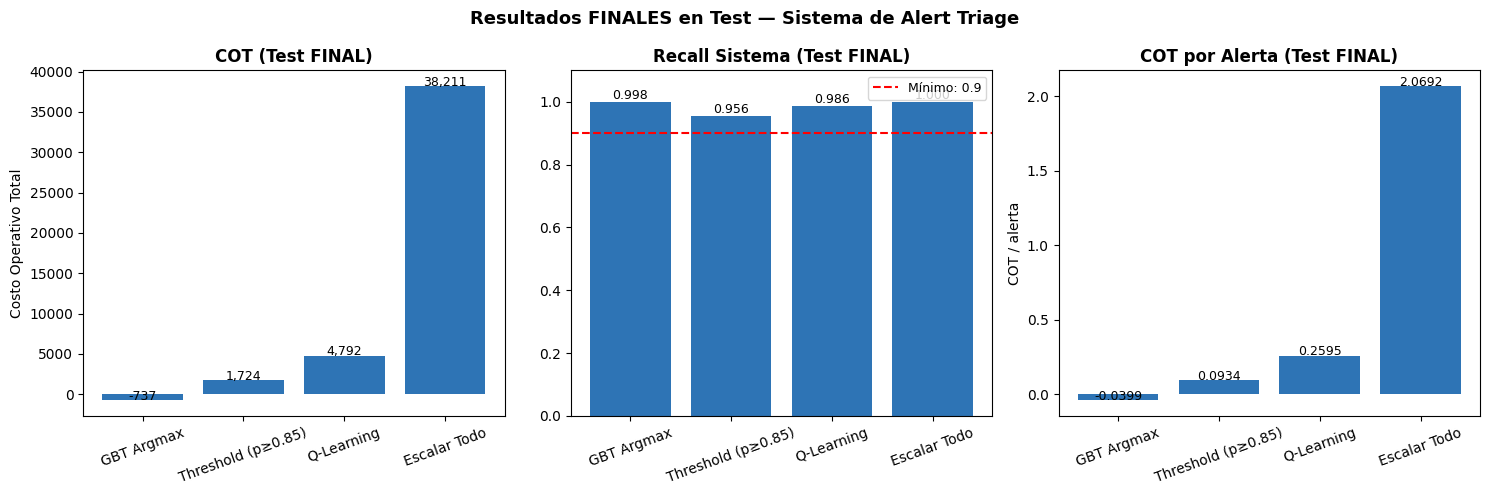

✓ Guardado: reports/12_policy_comparison_test_FINAL.png


In [14]:
# Visualización final
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

policy_names_t = comp_test['policy'].tolist()
colors_test = ['#C00000' if not r else '#2E74B5'
               for r in comp_test['recall_OK'].tolist()]

# COT
axes[0].bar(policy_names_t, comp_test['COT'], color=colors_test)
axes[0].set_title('COT (Test FINAL)', fontweight='bold')
axes[0].set_ylabel('Costo Operativo Total')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(comp_test['COT']):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=9)

# Recall
axes[1].bar(policy_names_t, comp_test['recall_sistema'], color=colors_test)
axes[1].axhline(config['recall_threshold'], color='red', linestyle='--', linewidth=1.5,
                label=f'Mínimo: {config["recall_threshold"]}')
axes[1].set_title('Recall Sistema (Test FINAL)', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(comp_test['recall_sistema']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# COT/alerta (normalizado)
axes[2].bar(policy_names_t, comp_test['COT_por_alerta'], color=colors_test)
axes[2].set_title('COT por Alerta (Test FINAL)', fontweight='bold')
axes[2].set_ylabel('COT / alerta')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(comp_test['COT_por_alerta']):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Resultados FINALES en Test — Sistema de Alert Triage', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/12_policy_comparison_test_FINAL.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: reports/12_policy_comparison_test_FINAL.png')

## 10. Resumen ejecutivo del sistema

In [15]:
print('\n' + '='*60)
print('RESUMEN EJECUTIVO — Sistema de Detección de Anomalías')
print('='*60)
print('SecureOps MX — MSSP SOC | NSL-KDD | CRISP-DM')
print()

# Mejor política que cumple constraint de recall
valid_policies = comp_test[comp_test['recall_OK']].sort_values('COT')
if len(valid_policies) > 0:
    best = valid_policies.iloc[0]
    print(f"✓ POLÍTICA ÓPTIMA: {best['policy']}")
    print(f"  COT total:       {best['COT']:,.1f}")
    print(f"  COT por alerta:  {best['COT_por_alerta']:.4f}")
    print(f"  Recall sistema:  {best['recall_sistema']:.4f} ≥ {config['recall_threshold']} ✓")
    print(f"  F1 binario:      {best['f1_binario']:.4f}")
    print(f"  % alertas ignoradas:  {best['pct_IGNORAR']:.1%}")
    print(f"  % alertas escaladas:  {best['pct_ESCALAR']:.1%}")
else:
    print('⚠ Ninguna política cumple el constraint de recall ≥',
          config['recall_threshold'])
    print('  Considerar rebajar epsilon_end o aumentar n_epochs')

print()
# Comparativa vs baseline más simple
escalate_all = comp_test[comp_test['policy'] == 'Escalar Todo'].iloc[0]
if len(valid_policies) > 0:
    savings = escalate_all['COT'] - best['COT']
    savings_pct = savings / escalate_all['COT'] * 100
    print(f"  vs. 'Escalar Todo': ahorro de COT = {savings:,.1f} ({savings_pct:.1f}%)")

print()
print('→ Siguiente paso: 05_dashboard.py (Streamlit)')
print('='*60)


RESUMEN EJECUTIVO — Sistema de Detección de Anomalías
SecureOps MX — MSSP SOC | NSL-KDD | CRISP-DM

✓ POLÍTICA ÓPTIMA: GBT Argmax
  COT total:       -737.0
  COT por alerta:  -0.0399
  Recall sistema:  0.9979 ≥ 0.9 ✓
  F1 binario:      0.9948
  % alertas ignoradas:  53.2%
  % alertas escaladas:  46.8%

  vs. 'Escalar Todo': ahorro de COT = 38,948.0 (101.9%)

→ Siguiente paso: 05_dashboard.py (Streamlit)
